In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
#get data
jordan = pd.read_csv('data/jordan-river.csv')
bear = pd.read_csv('data/bear-river.csv')
weber = pd.read_csv('data/weber-river.csv')

cols_to_drop = [
    'x', 'y', 'id', 'time_series_id', 'monitoring_location_id',
    'parameter_code', 'statistic_id',
    'approval_status', 'qualifier', 'last_modified'
]

for river in [jordan, bear, weber]:
    river['time'] = pd.to_datetime(river['time'])
    river.drop(cols_to_drop, axis=1, inplace=True)
    river.sort_values('time', inplace=True)
    river['days'] = (river['time'] - river['time'].min()).dt.days
#combine
df = jordan.merge(bear, on="time", how="outer")
df = df.merge(weber, on="time", how="outer")
df['value'] = df['value'] + df['value_x'] + df['value_y']
df['value'] = df['value'] * 0.0283168 #conversion to cubic meters
df.drop(['unit_of_measure_x', 'unit_of_measure_y', 'value_x', 'value_y', 'days_x', 'days_y'], axis=1, inplace=True)
df.drop('unit_of_measure', axis=1, inplace=True)

In [4]:
#fit sinusoidal wave
x = df["days"].to_numpy()
y = df["value"].to_numpy()

def sinusoid(t, A, B, phi, C):
    return A * np.sin(B * t + phi) + C

A0 = (y.max() - y.min()) / 2
B0 = 2 * np.pi / 365.25
phi0 = 0
C0 = y.mean()

params, _ = curve_fit(sinusoid, x, y, p0=[A0, B0, phi0, C0])
A_fit, B_fit, phi_fit, C_fit = params

df["fit"] = sinusoid(df["days"], A_fit, B_fit, phi_fit, C_fit)



In [5]:
df.head()

,time,value,days,fit
0,1998-10-24,73.567046,0,20.391395
1,1998-10-25,74.076749,1,20.640755
2,1998-10-26,88.744851,2,20.897452
3,1998-10-27,79.768426,3,21.161412
4,1998-10-28,83.194758,4,21.432555


In [6]:
#fit attempt 2
def seasonal_two_harmonics(t, A1, phi1, A2, phi2, C):
    omega = 2 * np.pi / 365
    return (
        A1 * np.sin(omega * t + phi1)
        + A2 * np.sin(2 * omega * t + phi2)
        + C
    )

p0 = [
    (y.max() - y.min()) / 2, 0,
    (y.max() - y.min()) / 4, 0,
    y.mean()
]

params2, _ = curve_fit(seasonal_two_harmonics, x, y)
print(params2)
df["fit2"] = seasonal_two_harmonics(df["days"], *params2)

[-28.97393599 -23.20200893 -18.43745932   4.29250411  45.52330359]


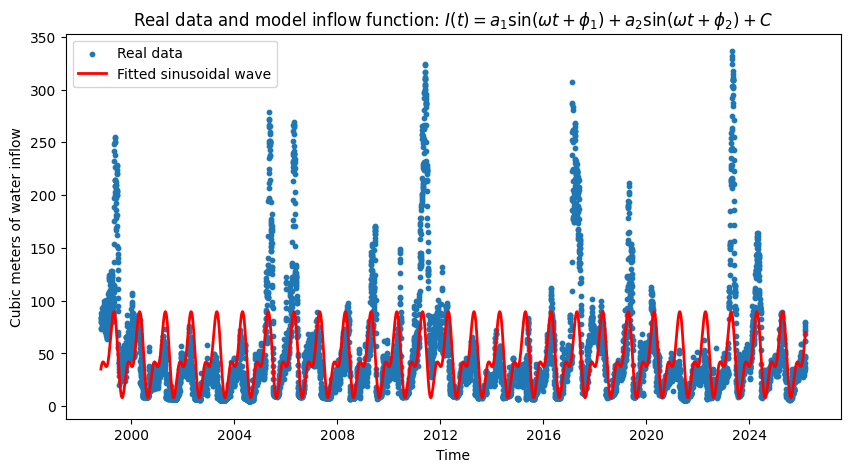

In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["value"], s=10, label="Real data")
plt.plot(df["time"], df["fit2"], linewidth=2, label="Fitted sinusoidal wave", c='r')
plt.title(r"Real data and model inflow function: $I(t) = a_1\sin(\omega t + \phi_1) + a_2\sin(\omega t + \phi_2) + C$")
plt.xlabel("Time")
plt.ylabel("Cubic meters of water inflow")
plt.legend()
plt.savefig('images/basic_inflow.png')
plt.show()

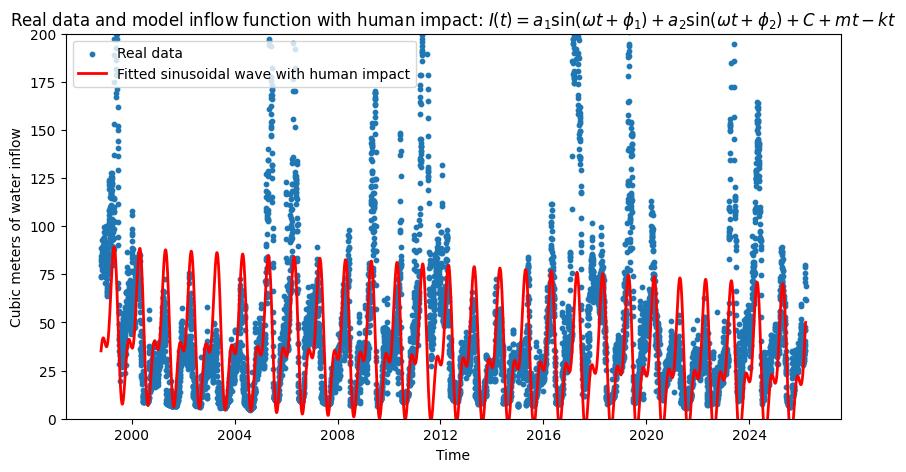

In [8]:
#to account for human impact, add a negative linear trend
seasonal_two_harmonics_human = lambda t, A1, phi1, A2, phi2, C, nu: (
    A1 * np.sin(2 * np.pi / 365 * t + phi1)
    + A2 * np.sin(2 * 2 * np.pi / 365 * t + phi2)
    + C
)   - (nu * t)

df['fit3'] = seasonal_two_harmonics_human(df["days"], *params2,  0.002)
plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["value"], s=10, label="Real data")
plt.plot(df["time"], df["fit3"], linewidth=2, label="Fitted sinusoidal wave with human impact", c='r')
plt.title(r"Real data and model inflow function with human impact: $I(t) = a_1\sin(\omega t + \phi_1) + a_2\sin(\omega t + \phi_2) + C + mt - kt$")
plt.ylim(0, 200)
plt.xlabel("Time")
plt.ylabel("Cubic meters of water inflow")
plt.legend()
plt.show()